In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pandas.api.types import CategoricalDtype

from category_encoders import MEstimateEncoder
from category_encoders import CatBoostEncoder

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Set Matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Mute warnings
warnings.filterwarnings('ignore')

## Data Preprocessing ##

- **Load** the data from CSV files
- **Clean** the data to fix any errors or inconsistencies
- **Encode** the statistical data type (numeric, categorical)
- **Impute** any missing values

In [2]:
def load_data():
    # Read data
    data_dir = Path("/kaggle/input/datasets/joelzcharia/contraceptive-prevalence-survey/1987 Indonesia Contraception Prevalence Study.csv")
    df = pd.read_csv(data_dir)
    return df
    # Preprocessing
    # df = clean(df)
    # df = encode(df)
    # df = impute(df)

In [3]:
# Loading and Inspecting the Data

df = load_data()
print(df.shape, "\n")
print(df.dtypes, "\n")
print(df.head(10), "\n")
print(df.describe(), "\n")
print(df.info(), "\n")



(1473, 10) 

Age                          int64
Education                    int64
Partner Education            int64
Number of Children           int64
Religion = Islam             int64
Currently working            int64
Husband Occupation           int64
Standard of Living           int64
Media Exposure               int64
Contraceptive Method Used    int64
dtype: object 

   Age  Education  Partner Education   Number of Children  Religion = Islam  \
0   24          2                   3                   3                 1   
1   45          1                   3                  10                 1   
2   43          2                   3                   7                 1   
3   42          3                   2                   9                 1   
4   36          3                   3                   8                 1   
5   19          4                   4                   0                 1   
6   38          2                   3                   6           

In [4]:
# Check for Missing Data and Duplicated Data

df.isna().sum()
df.duplicated().sum()
df[df.duplicated()]

,Age,Education,Partner Education,Number of Children,Religion = Islam,Currently working,Husband Occupation,Standard of Living,Media Exposure,Contraceptive Method Used
79,38,4,4,1,1,0,1,4,0,1
167,26,4,4,1,1,1,1,4,0,1
224,47,4,4,4,1,1,1,4,0,1
270,30,4,4,2,1,1,1,4,0,1
299,26,4,4,1,1,1,1,4,0,1
394,29,4,4,0,1,0,2,4,0,1
414,20,2,3,3,1,1,3,4,0,1
462,36,4,4,3,1,1,1,4,0,2
492,37,4,4,3,1,1,1,4,0,2
528,29,4,4,2,1,0,1,3,0,2


In [5]:
# Recode Currently Working and Media Exposure to fix inverted coding
df["Currently working recoded"] = df["Currently working"].map({0:1, 1:0})
df["Media Exposure recoded"] = df["Media Exposure"].map({0:1, 1:0})

# Recode Contraceptive Method for more logical progression - 1 = none, 2 = short term, 3 = long term
df["Contraceptive Method Used recoded"] = df["Contraceptive Method Used"].map({1:1, 2:3, 3:2})
df[["Currently working recoded", "Media Exposure recoded", "Contraceptive Method Used recoded"]].head(10)



,Currently working recoded,Media Exposure recoded,Contraceptive Method Used recoded
0,0,1,1
1,0,1,1
2,0,1,1
3,0,1,1
4,0,1,1
5,0,1,1
6,0,1,1
7,1,1,1
8,0,1,1
9,0,0,1


In [6]:
# Create Age Groups

bins = [15, 19, 24, 29, 34, 39, 44, 49]
lab = ["15–19", "20–24", "25–29", "30–34", "35–39", "40–44", "45–49"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=lab, include_lowest=True)
df["Age Group"].value_counts()

Age Group
25–29    330
30–34    279
35–39    248
20–24    240
40–44    181
45–49    159
15–19     36
Name: count, dtype: int64

In [7]:
# Analyze percentage of women in each age group

age_distribution = (df['Age Group'].value_counts(normalize=True) * 100).round(2)

# pct_dist = df.groupby('Age Group').size()/len(df) * 100

print(age_distribution)

Age Group
25–29    22.40
30–34    18.94
35–39    16.84
20–24    16.29
40–44    12.29
45–49    10.79
15–19     2.44
Name: proportion, dtype: float64


In [8]:
# Analyze percentage of women in each age gourp using each contraceptive method

contra_perc = df.groupby('Age Group')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).round(2)

print(contra_perc)

Age Group  Contraceptive Method Used recoded
15–19      1                                    50.00
           2                                    41.67
           3                                     8.33
20–24      1                                    45.00
           2                                    40.83
           3                                    14.17
25–29      2                                    43.33
           1                                    38.79
           3                                    17.88
30–34      2                                    40.86
           1                                    34.77
           3                                    24.37
35–39      2                                    34.68
           1                                    34.27
           3                                    31.05
40–44      1                                    46.96
           3                                    33.15
           2                         

In [9]:
# Analyze percentage of women using each contraceptive method

contra_dist = df.groupby('Contraceptive Method Used recoded').size()/len(df) * 100

print(contra_dist)

Contraceptive Method Used recoded
1    42.701969
2    34.691107
3    22.606925
dtype: float64


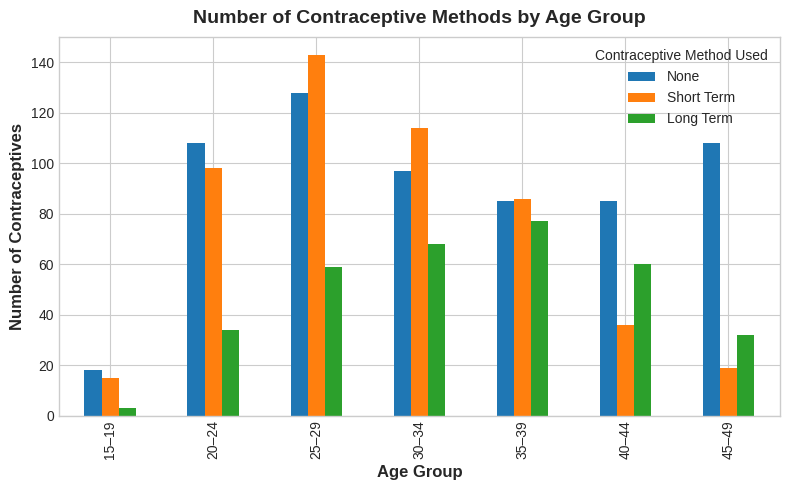

In [10]:
# Create Barchart for Age Distribution 1

counts = df.groupby(['Age Group', 'Contraceptive Method Used recoded']).size().unstack()
counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Number of Contraceptive Methods by Age Group' )

plt.xlabel('Age Group')
plt.ylabel('Number of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


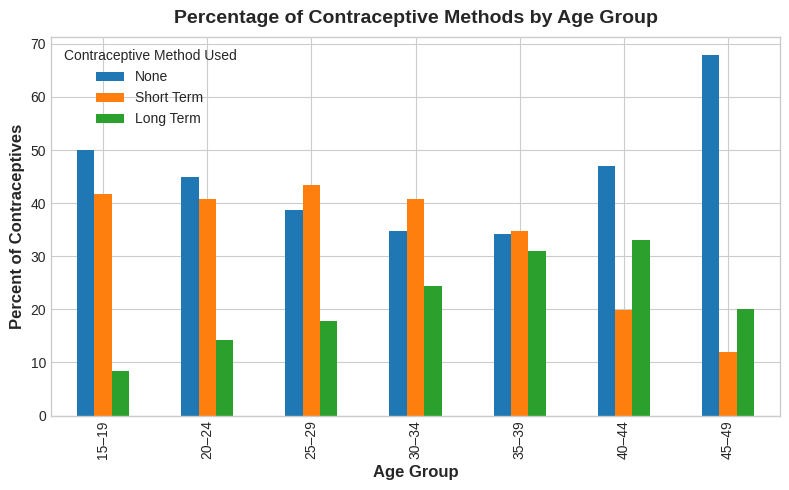

In [11]:
# Create Barchart for Age Distribution 1

per_counts = df.groupby('Age Group')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).unstack()
per_counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Percentage of Contraceptive Methods by Age Group' )

plt.xlabel('Age Group')
plt.ylabel('Percent of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


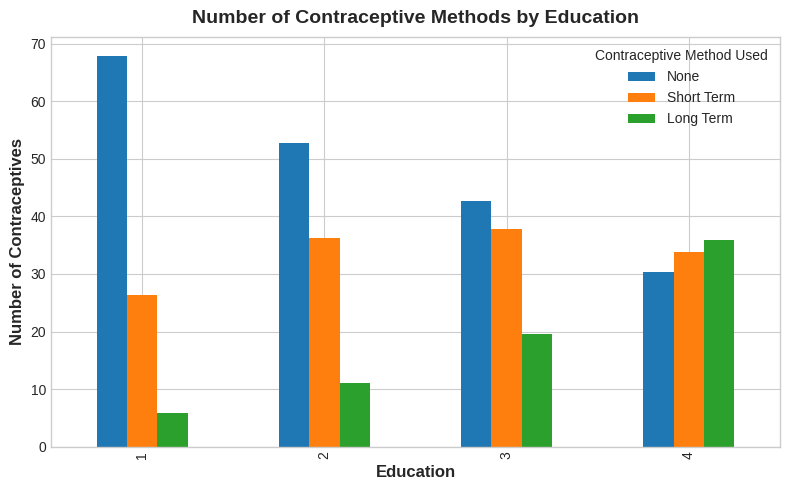

In [12]:
# Barchart 

# counts = df.groupby(['Education', 'Contraceptive Method Used recoded']).size().unstack()
counts = df.groupby('Education')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).unstack()
counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Number of Contraceptive Methods by Education' )

plt.xlabel('Education')
plt.ylabel('Number of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


<Axes: title={'center': 'Correlation between Sociodemographic char and Contraceptive Method'}>

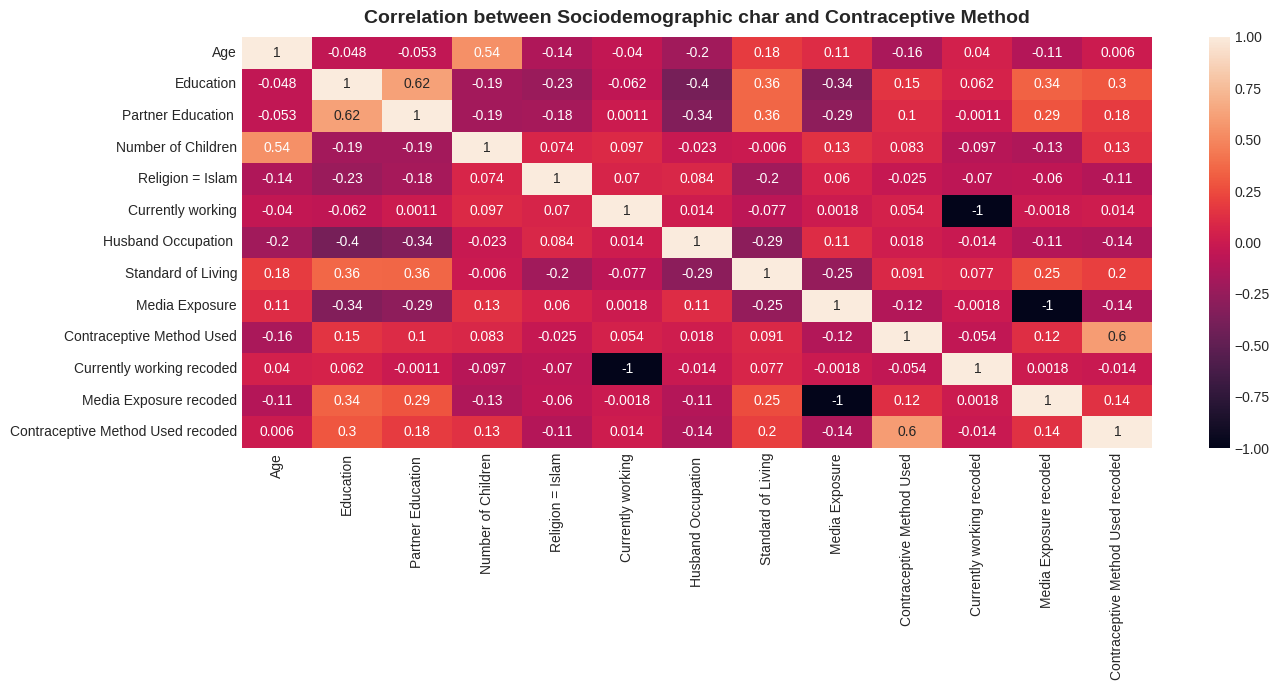

In [13]:
# Heatmap showing Correlation between the sociodemographic variables and contraceptive method used

plt.figure(figsize=(14,7))
plt.title("Correlation between Sociodemographic char and Contraceptive Method")

co_mtx = df.corr(numeric_only=True)
sns.heatmap(co_mtx, annot=True)


### Summary of Findings so far

* We have 1473 participants in this survey
* No duplicates and no missing values
* Lowest age is 16 and highest is 49 with the mean at 32
* The age group with the highest frequency is 25 - 29
* The freq of use of long term contraceptive increases with age group (although drops at 45 - 49)
* The extreme of age groups have the highest frequency of using no contraceptives
* The variables with highest correlation with contraceptive methods are Education, Standard of Living, Partner Education, Media Exposure, Number of children

In [14]:
# Remove old columns

df = df.drop(["Currently working", "Media Exposure", "Contraceptive Method Used"], axis=1)

In [15]:
df.head()

,Age,Education,Partner Education,Number of Children,Religion = Islam,Husband Occupation,Standard of Living,Currently working recoded,Media Exposure recoded,Contraceptive Method Used recoded,Age Group
0,24,2,3,3,1,2,3,0,1,1,20–24
1,45,1,3,10,1,3,4,0,1,1,45–49
2,43,2,3,7,1,3,4,0,1,1,40–44
3,42,3,2,9,1,3,3,0,1,1,40–44
4,36,3,3,8,1,3,2,0,1,1,35–39


In [16]:
# The nominative (unordered) categorical features

df["Husband Occupation "] = df["Husband Occupation "].astype("category")
df["Age Group"] = df["Age Group"].astype("object")


In [17]:
X = df.copy()
y = X.pop("Contraceptive Method Used recoded")

train_X, val_X, train_y, val_y = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

# Religion Islam, Currently Working, Husbands Occupation, Media Exposure



In [18]:
train_X = train_X.select_dtypes(exclude=['object'])
val_X = val_X.select_dtypes(exclude=['object'])

train_X = pd.get_dummies(train_X)
val_X = pd.get_dummies(val_X)
train_X, val_X = train_X.align(val_X, join='left', axis=1)

In [19]:
my_model_1 = XGBRegressor(random_state=0)
my_model_1.fit(train_X, train_y)
predictions_1 = my_model_1.predict(val_X)
print("Mean Absolute Error: " + str(mean_absolute_error(predictions_1, val_y))
     )

# Calculate MAE
mae_1 = mean_absolute_error(predictions_1, val_y)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_1)

Mean Absolute Error: 0.6328586339950562
Mean Absolute Error: 0.6328586339950562


In [20]:
# Using XGBRegressor

my_model_2 = XGBRegressor(n_estimators=100, early_stopping_rounds=5, learning_rate=0.05, n_jobs=4)
my_model_2.fit(train_X, train_y, eval_set = [(val_X, val_y)], verbose=False)
predictions_2 = my_model_2.predict(val_X)
mae = mean_absolute_error(predictions_2, val_y)
print("Mean Absolute Error:" , mae)


Mean Absolute Error: 0.5490401983261108


In [21]:
# def score_dataset(X_train, X_valid, y_train, y_valid):
#     model = RandomForestRegressor(n_estimators=100, random_state=0)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_valid)
#     return mean_absolute_error(y_valid, preds)

In [22]:
# s = (train_X.dtypes == 'object')
# ordinal_cols = list(s[s].index)

# s = (train_X.dtypes == 'category')
# nominal_cols = list(s[s].index)

# s = (train_X.dtypes == 'int64')
# numerical_cols = list(s[s].index)

# print("Categorical variables:")
# print(numerical_cols)

# print(X.dtypes, "\n")


In [23]:
# drop_X_train = train_X.select_dtypes(exclude=['category'])
# drop_X_valid = val_X.select_dtypes(exclude=['category'])

# print("MAE from Approach 1:")
# print(score_dataset(drop_X_train, drop_X_valid, train_y, val_y))

In [24]:
# from sklearn.preprocessing import OneHotEncoder

# OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(train_X[object_cols]))
# OH_cols_valid = pd.DataFrame(OH_encoder.transform(val_X[object_cols]))

# # One-hot encoding removed index; put it back
# OH_cols_train.index = train_X.index
# OH_cols_valid.index = val_X.index

# # Remove categorical columns (will replace with one-hot encoding)
# num_X_train = train_X.drop(object_cols, axis=1)
# num_X_valid = val_X.drop(object_cols, axis=1)

# # Add one-hot encoded columns to numerical features
# OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
# OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# # Ensure all columns have string type
# OH_X_train.columns = OH_X_train.columns.astype(str)
# OH_X_valid.columns = OH_X_valid.columns.astype(str)

# # OH_X_train

# # print("MAE from Approach 2: (One-Hot Encoding)") 
# # print(score_dataset(OH_X_train, OH_X_valid, train_y, val_y))

# # 0.5771344632768363
# # 0.5817399112187248
# # 0.579715617433414

In [25]:
# rf_model = RandomForestRegressor(random_state=1)
# rf_model.fit(train_X, train_y)
# rf_val_predictions = rf_model.predict(val_X)
# rf_val_mae = mean_absolute_error(val_predictions, val_y)
# print("Validation MAE for Random Forest Model: {}".format(rf_val_mae))


In [26]:
# # Pipeline

# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.model_selection import cross_val_score



# # Preprocessing for numerical data
# numerical_transformer = SimpleImputer(strategy='mean')

# # Preprocessing for nominal data
# nominal_transformer = Pipeline(steps=[
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# # Preprocessing for ordinal data
# ordinal_transformer = Pipeline(steps=[
#     ('ordinal', OrdinalEncoder())
# ])


# # Bundle preprocessing for numerical and categorical data
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numerical_transformer, numerical_cols),
#         ('nom', nominal_transformer, nominal_cols),
#         ('ord', ordinal_transformer, ordinal_cols)
#     ], 
#     # remainder='passthrough'
# )

# model = RandomForestRegressor(n_estimators=100, random_state=0)

# # Bundle preprocessing and modeling code in a pipeline
# my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
#                               ('model', model)
#                              ])

# # Preprocessing of training data, fit model 
# my_pipeline.fit(train_X, train_y)

# # Preprocessing of validation data, get predictions
# preds = my_pipeline.predict(val_X)

# # Evaluate the model
# score = mean_absolute_error(val_y, preds)

# scores = -1 * cross_val_score(my_pipeline, X, y,
#                               cv=5,
#                               scoring='neg_mean_absolute_error')


# print('MAE from pipeline:', score)
# print("MAE scores:\n", scores)


# # 0.5773532687651332
# # 0.5817399112187248
# # 0.5831719531880548


In [27]:
# def get_score(n_estimators):
#     """Return the average MAE over 3 CV folds of random forest model.
    
#     Keyword argument:
#     n_estimators -- the number of trees in the forest
#     """
#     model = RandomForestRegressor(n_estimators, random_state=0)

#     my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
#                               ('model', model)
#                              ])

#     scores = -1 * cross_val_score(my_pipeline, X, y,
#                               cv=3,
#                               scoring='neg_mean_absolute_error')

#     return scores.mean()


In [28]:
# results = {}

# for i in range(50, 450, 50):
#     results[i] = get_score(i)

# print(results)

In [29]:
# import matplotlib.pyplot as plt
# %matplotlib inline

# plt.plot(list(results.keys()), list(results.values()))
# plt.show()